In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

In [18]:
df = pd.read_csv("/content/WineQT.csv")

Univariate

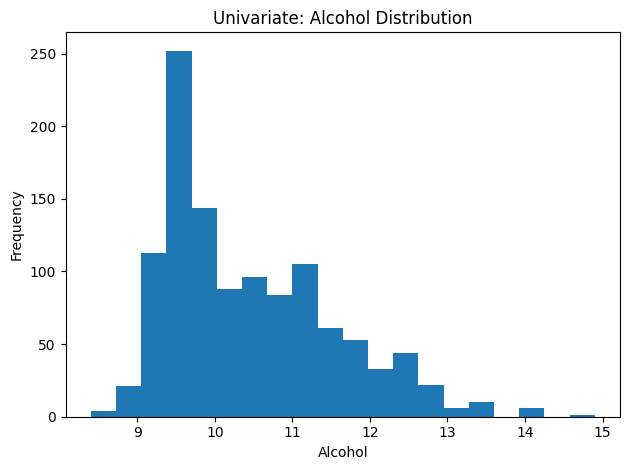

In [19]:
plt.figure()
plt.hist(df["alcohol"], bins=20)
plt.title("Univariate: Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Discrete, categorical attribute in 1-D

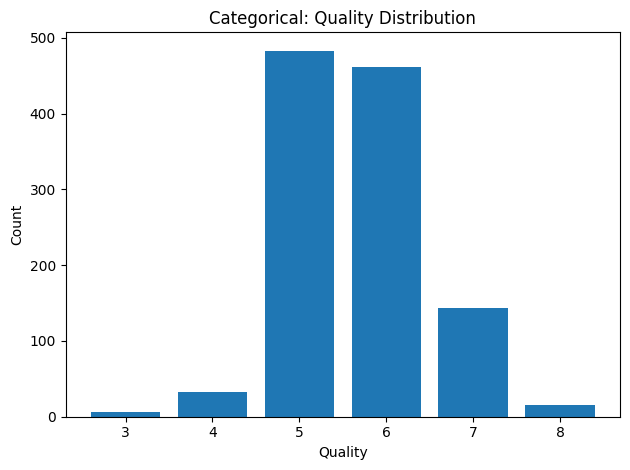

In [20]:
plt.figure()
counts = df["quality"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Categorical: Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Bivariate Analysis (Two Continuous Numeric Attributes: Alcohol vs Density)

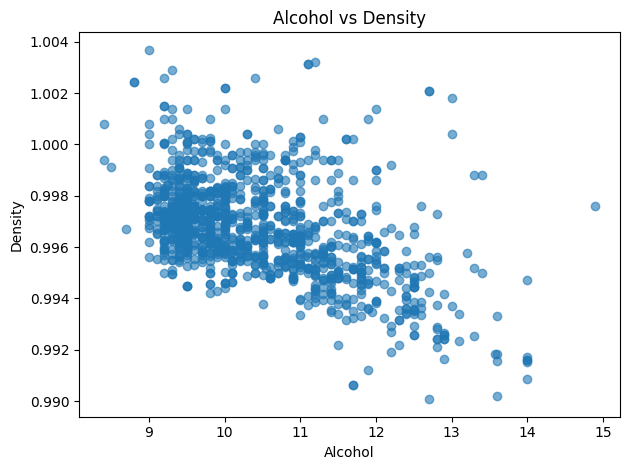

In [21]:
plt.figure()
plt.scatter(df["alcohol"], df["density"], alpha=0.6)
plt.title("Alcohol vs Density")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


Joint Plot (Alcohol vs Quality)

/tmp/ipython-input-1272236657.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


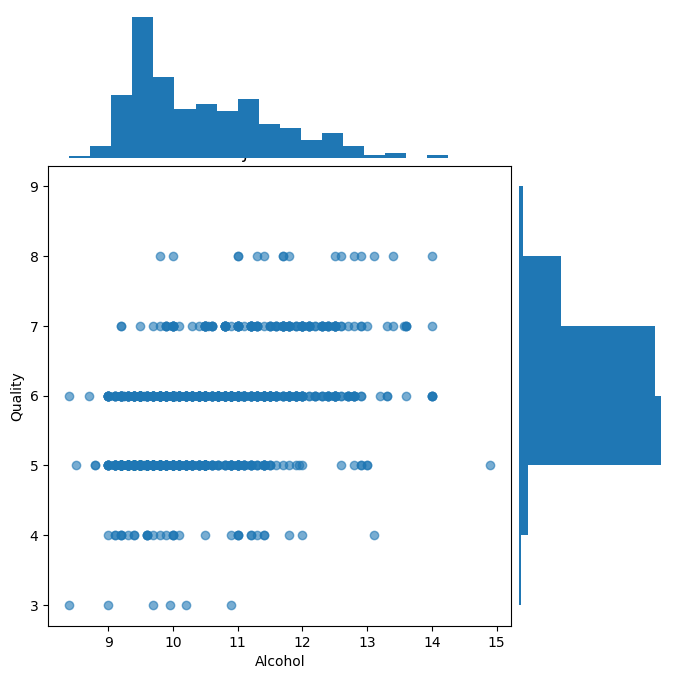

In [22]:
x = df["alcohol"]
y = df["quality"]
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_xhist = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

ax_main.scatter(x, y, alpha=0.6)
ax_main.set_xlabel("Alcohol")
ax_main.set_ylabel("Quality")
ax_main.set_title("Joint Plot")

ax_xhist.hist(x, bins=20)
ax_xhist.axis("off")

ax_yhist.hist(y, bins=range(int(y.min()), int(y.max()) + 2), orientation="horizontal")
ax_yhist.axis("off")

plt.tight_layout()
plt.show()

Boxplot (Alcohol Distribution Across Quality Levels)

/tmp/ipython-input-201628228.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(q) for q in qualities], showmeans=True)


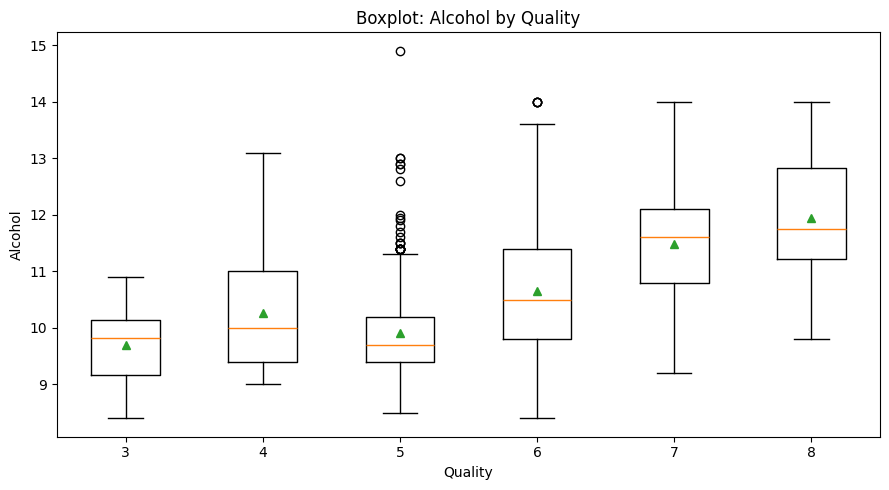

In [23]:
qualities = sorted(df["quality"].unique())
data = [df.loc[df["quality"] == q, "alcohol"].values for q in qualities]

plt.figure(figsize=(9, 5))
plt.boxplot(data, labels=[str(q) for q in qualities], showmeans=True)
plt.title("Boxplot: Alcohol by Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()

Violin Plot (Alcohol Distribution Across Quality Levels)

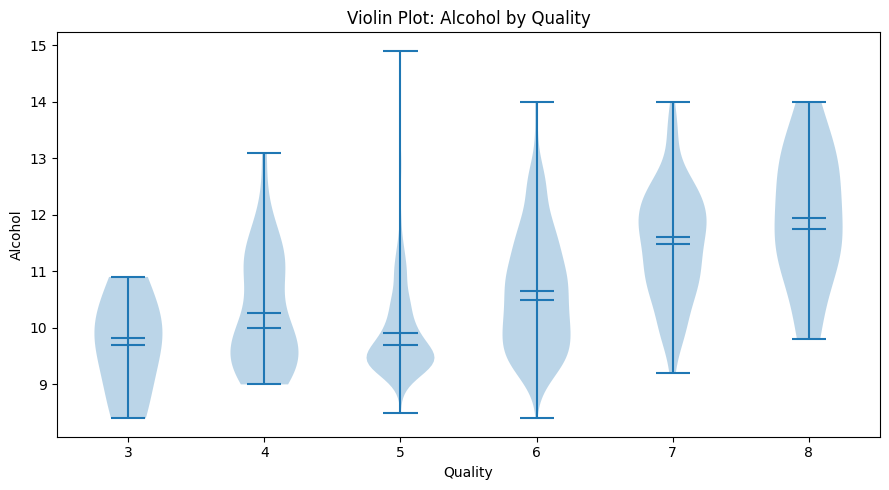

In [24]:
plt.figure(figsize=(9, 5))
plt.violinplot(data, showmeans=True, showmedians=True)
plt.title("Violin Plot: Alcohol by Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.xticks(ticks=np.arange(1, len(qualities) + 1), labels=[str(q) for q in qualities])
plt.tight_layout()
plt.show()


Multivariate / High-Dimensional (Parallel Coordinates)

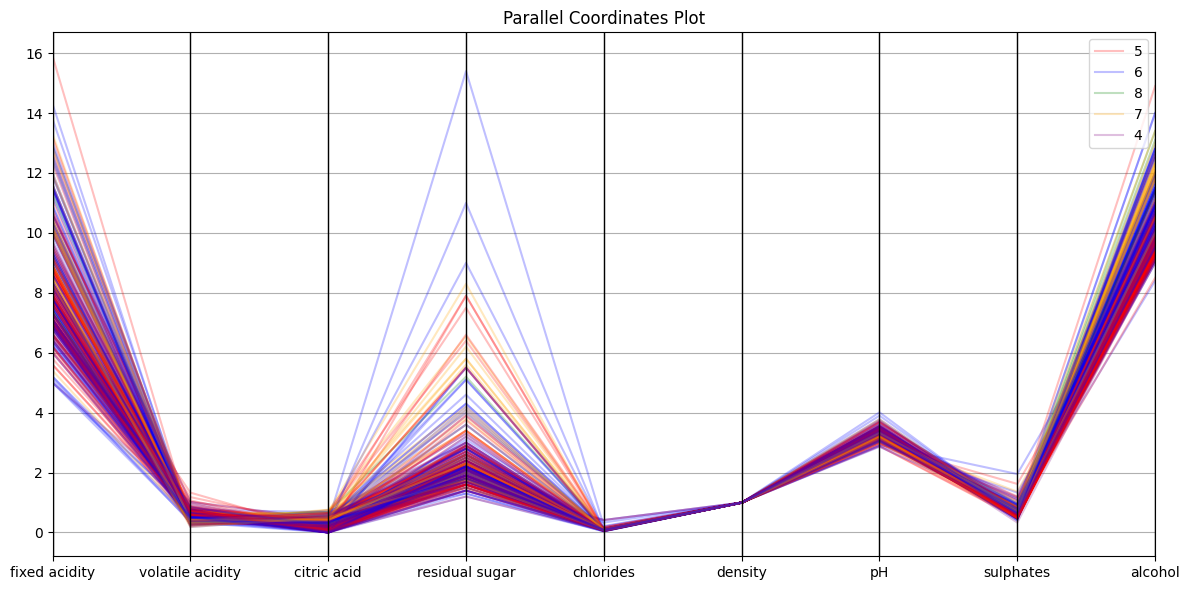

In [26]:
features = ["fixed acidity", "volatile acidity", "citric acid",
            "residual sugar", "chlorides", "density",
            "pH", "sulphates", "alcohol"]

cols = [c for c in features if c in df.columns] + ["quality"]

colors = ["red", "blue", "green", "orange", "purple",
          "brown", "pink", "gray", "cyan", "black"]
dfx = df[cols].dropna()
if len(dfx) > 300:
    dfx = dfx.sample(300, random_state=42)

plt.figure(figsize=(12, 6))
parallel_coordinates(
    dfx,
    class_column="quality",
    color=colors[:len(dfx["quality"].unique())],
    alpha=0.25
)
plt.title("Parallel Coordinates Plot")
plt.tight_layout()
plt.show()


3D Scatter Plot (Alcohol, Density, pH)

In [ ]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df["alcohol"], df["density"], df["pH"], alpha=0.6)
ax.set_title("3D Scatter: Alcohol vs Density vs pH")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Density")
ax.set_zlabel("pH")
plt.tight_layout()
plt.show()

Distribution of Alcohol Across Different Quality Levels (Small Multiples Histogram)

In [ ]:
qualities = sorted(df["quality"].unique())
cols = 3
rows = int(np.ceil(len(qualities) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, q in enumerate(qualities):
    vals = df.loc[df["quality"] == q, "alcohol"].dropna()
    axes[i].hist(vals, bins=20)
    axes[i].set_title(f"Quality {q}")
    axes[i].set_xlabel("Alcohol")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()